In [45]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv(r'C:\Users\Nitro V15\OneDrive\Documents\Intership\dataset\dataset_12000_records.csv')
print(df)

      Patient_ID  Age  Gender        BMI Smoking_Status Alcohol_Consumption  \
0       PT_00001   65  Female  25.564766             No                  No   
1       PT_00002   83    Male  30.503110            Yes                 Yes   
2       PT_00003   76    Male  21.934792             No                  No   
3       PT_00004   72  Female  22.048039             No                 Yes   
4       PT_00005   54    Male  27.102739             No                  No   
...          ...  ...     ...        ...            ...                 ...   
11995   PT_11996   38  Female  26.447694             No                  No   
11996   PT_11997   87  Female  31.303370             No                 Yes   
11997   PT_11998   62    Male  35.160424            Yes                  No   
11998   PT_11999   85    Male  28.831126             No                  No   
11999   PT_12000   68    Male  30.701425            Yes                  No   

       Exercise_Frequency  Hypertension  Diabetes  

In [47]:
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Smoking_Status',
       'Alcohol_Consumption', 'Exercise_Frequency', 'Hypertension', 'Diabetes',
       'Chronic_Kidney_Disease', 'Coronary_Artery_Disease', 'Previous_Stroke',
       'Atrial_Fibrillation', 'Previous_HF_Admissions',
       'Previous_Hospital_Admissions', 'Heart_Failure_Type', 'NYHA_Class',
       'Ejection_Fraction', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate',
       'Oxygen_Saturation', 'Creatinine', 'Sodium', 'Potassium', 'Hemoglobin',
       'Blood_Glucose', 'BNP', 'Length_of_Stay', 'ICU_Admission',
       'Emergency_Admission', 'Beta_Blocker', 'ACE_ARB', 'Diuretic',
       'SGLT2_Inhibitor', 'Readmitted_30_Days'],
      dtype='object')


In [48]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    12000 non-null  object 
 1   Age                           12000 non-null  int64  
 2   Gender                        12000 non-null  object 
 3   BMI                           12000 non-null  float64
 4   Smoking_Status                12000 non-null  object 
 5   Alcohol_Consumption           12000 non-null  object 
 6   Exercise_Frequency            12000 non-null  int64  
 7   Hypertension                  12000 non-null  int64  
 8   Diabetes                      12000 non-null  int64  
 9   Chronic_Kidney_Disease        12000 non-null  int64  
 10  Coronary_Artery_Disease       12000 non-null  int64  
 11  Previous_Stroke               12000 non-null  int64  
 12  Atrial_Fibrillation           12000 non-null  int64  
 13  P

In [49]:
print(df.isnull().sum())

Patient_ID                      0
Age                             0
Gender                          0
BMI                             0
Smoking_Status                  0
Alcohol_Consumption             0
Exercise_Frequency              0
Hypertension                    0
Diabetes                        0
Chronic_Kidney_Disease          0
Coronary_Artery_Disease         0
Previous_Stroke                 0
Atrial_Fibrillation             0
Previous_HF_Admissions          0
Previous_Hospital_Admissions    0
Heart_Failure_Type              0
NYHA_Class                      0
Ejection_Fraction               0
Systolic_BP                     0
Diastolic_BP                    0
Heart_Rate                      0
Oxygen_Saturation               0
Creatinine                      0
Sodium                          0
Potassium                       0
Hemoglobin                      0
Blood_Glucose                   0
BNP                             0
Length_of_Stay                  0
ICU_Admission 

In [50]:
print(df.isnull())

       Patient_ID    Age  Gender    BMI  Smoking_Status  Alcohol_Consumption  \
0           False  False   False  False           False                False   
1           False  False   False  False           False                False   
2           False  False   False  False           False                False   
3           False  False   False  False           False                False   
4           False  False   False  False           False                False   
...           ...    ...     ...    ...             ...                  ...   
11995       False  False   False  False           False                False   
11996       False  False   False  False           False                False   
11997       False  False   False  False           False                False   
11998       False  False   False  False           False                False   
11999       False  False   False  False           False                False   

       Exercise_Frequency  Hypertension

In [51]:
df.dtypes

Patient_ID                       object
Age                               int64
Gender                           object
BMI                             float64
Smoking_Status                   object
Alcohol_Consumption              object
Exercise_Frequency                int64
Hypertension                      int64
Diabetes                          int64
Chronic_Kidney_Disease            int64
Coronary_Artery_Disease           int64
Previous_Stroke                   int64
Atrial_Fibrillation               int64
Previous_HF_Admissions            int64
Previous_Hospital_Admissions      int64
Heart_Failure_Type               object
NYHA_Class                        int64
Ejection_Fraction               float64
Systolic_BP                     float64
Diastolic_BP                    float64
Heart_Rate                      float64
Oxygen_Saturation               float64
Creatinine                      float64
Sodium                          float64
Potassium                       float64


In [52]:
dup_count = df.duplicated().sum()
print(dup_count)

0


In [53]:
X = df.drop(['Patient_ID','Readmitted_30_Days', 'Gender'], axis=1)
y= df['Readmitted_30_Days']

In [54]:
print("Target:", y.name)
print("Target in X:", y.name in X.columns)

Target: Readmitted_30_Days
Target in X: False


In [55]:
print(X.columns.tolist())

['Age', 'BMI', 'Smoking_Status', 'Alcohol_Consumption', 'Exercise_Frequency', 'Hypertension', 'Diabetes', 'Chronic_Kidney_Disease', 'Coronary_Artery_Disease', 'Previous_Stroke', 'Atrial_Fibrillation', 'Previous_HF_Admissions', 'Previous_Hospital_Admissions', 'Heart_Failure_Type', 'NYHA_Class', 'Ejection_Fraction', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Oxygen_Saturation', 'Creatinine', 'Sodium', 'Potassium', 'Hemoglobin', 'Blood_Glucose', 'BNP', 'Length_of_Stay', 'ICU_Admission', 'Emergency_Admission', 'Beta_Blocker', 'ACE_ARB', 'Diuretic', 'SGLT2_Inhibitor']


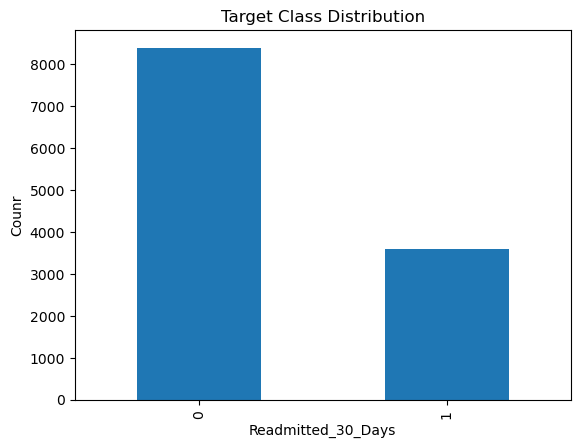

In [56]:
y.value_counts().plot(kind='bar')
plt.xlabel('Readmitted_30_Days')
plt.ylabel('Counr')
plt.title("Target Class Distribution")
plt.show()

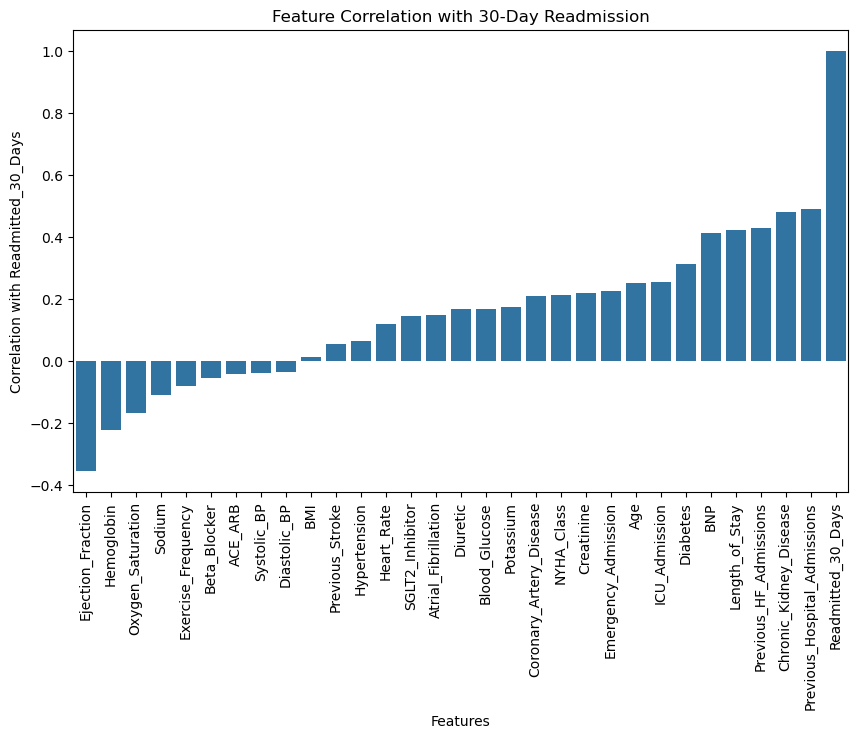

In [57]:
corr = df.corr(numeric_only=True)['Readmitted_30_Days'].sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=corr.index, y=corr.values)

plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Correlation with Readmitted_30_Days')
plt.title('Feature Correlation with 30-Day Readmission')

plt.show()

In [58]:
cat_features = ['Smoking_Status',
    'Alcohol_Consumption',
    'Heart_Failure_Type']

num_features = ['Age',
    'BMI',
    'Ejection_Fraction',
    'Systolic_BP',
    'Diastolic_BP',
    'Heart_Rate',
    'Oxygen_Saturation',
    'Creatinine',
    'Sodium',
    'Potassium',
    'Hemoglobin',
    'Blood_Glucose',
    'BNP']

In [59]:
preprocess = ColumnTransformer(
    transformers=[
        ('num_features', StandardScaler(), num_features),
        ('cat_features', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
log_model = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', LogisticRegression(max_iter=1000))
])
tree_model = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', DecisionTreeClassifier())
])
knn_model = Pipeline([
    ('preprocessing', preprocess),
    ('classifier', KNeighborsClassifier())
])

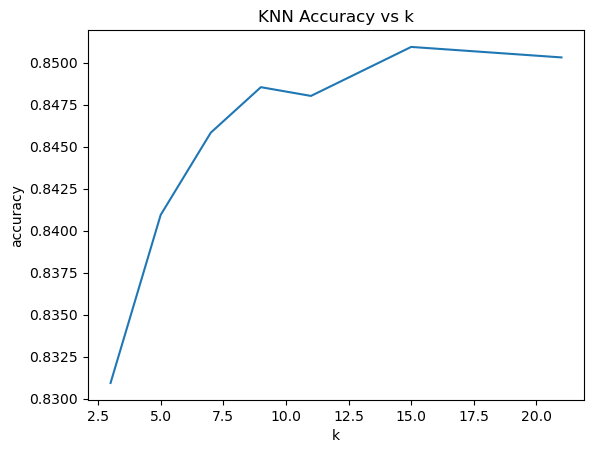

In [62]:
k = [3, 5, 7, 9, 11, 15, 21]
knn_result = []
for i in k:
  knn_pipeline = knn_model.set_params(classifier__n_neighbors=i)
  scores = cross_val_score(knn_pipeline, X_train, y_train, cv=5, scoring='accuracy')
  knn_result.append({'k': i, 'accuracy': scores.mean()})
knn_result_df = pd.DataFrame(knn_result)
plt.plot(knn_result_df['k'], knn_result_df['accuracy'])
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('KNN Accuracy vs k')
plt.show()

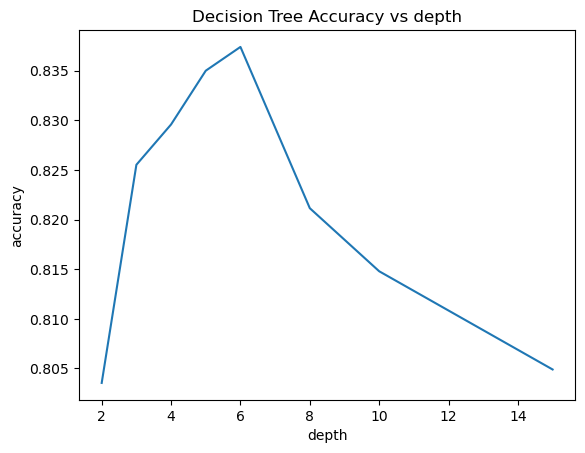

In [63]:
depth = [2, 3, 4, 5, 6, 8, 10, 15]
tree_result = []
for i in depth:
  tree_pipeline = tree_model.set_params(classifier__max_depth=i)
  scores = cross_val_score(tree_pipeline, X_train, y_train, cv=5, scoring='accuracy')
  tree_result.append({'depth': i, 'accuracy': scores.mean()})
tree_result_df = pd.DataFrame(tree_result)
plt.plot(tree_result_df['depth'], tree_result_df['accuracy'])
plt.xlabel('depth')
plt.ylabel('accuracy')
plt.title('Decision Tree Accuracy vs depth')
plt.show()

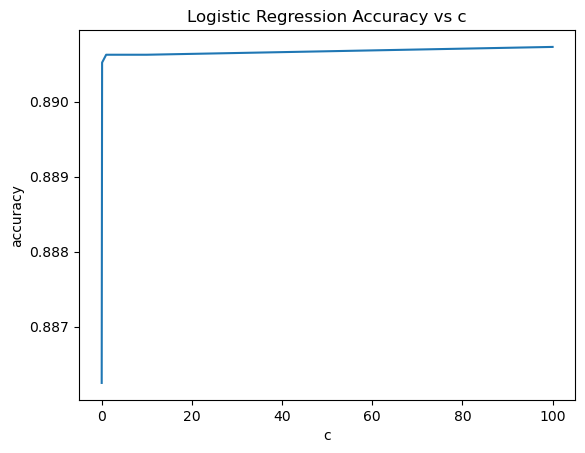

In [64]:
c = [0.01, 0.1, 1, 10, 100]
log_result = []
for i in c:
  log_pipeline = log_model.set_params(classifier__C=i)
  scores = cross_val_score(log_pipeline, X_train, y_train, cv=5, scoring='accuracy')
  log_result.append({'c': i, 'accuracy': scores.mean()})
log_result_df = pd.DataFrame(log_result)
plt.plot(log_result_df['c'], log_result_df['accuracy'])
plt.xlabel('c')
plt.ylabel('accuracy')
plt.title('Logistic Regression Accuracy vs c')
plt.show()

In [65]:
models = {
    "Logistic Regression": log_model.set_params(classifier__C=1, classifier__max_iter=1000),
    "Decision Tree": tree_model.set_params(classifier__max_depth=6),
    "K-Nearest Neighbors": knn_model.set_params(classifier__n_neighbors=15)
}

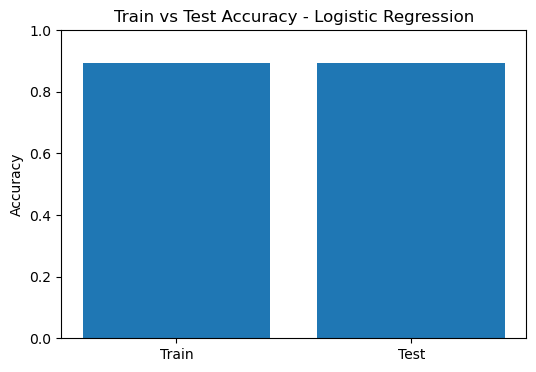

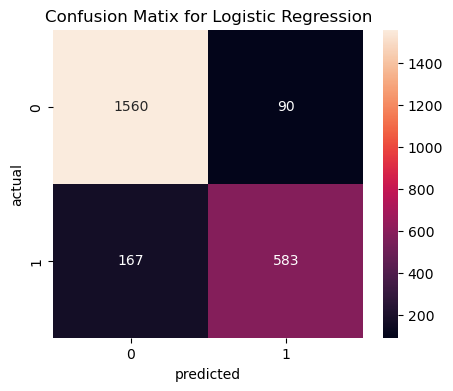

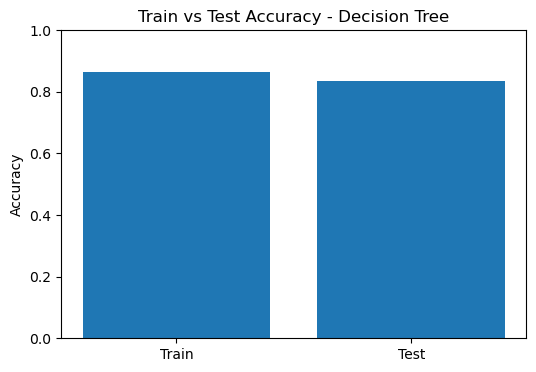

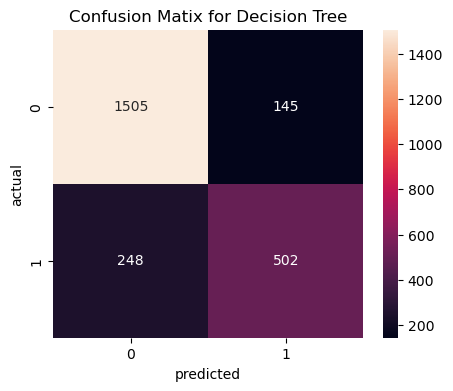

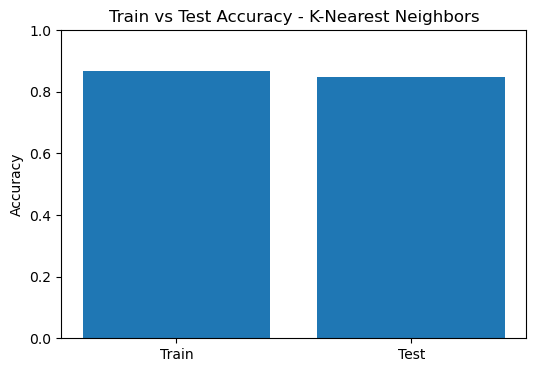

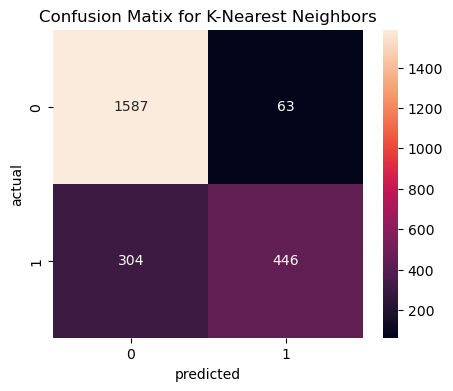

In [66]:
result = []
for name, algo in models.items():
  algo.fit(X_train, y_train)
  y_pred = algo.predict(X_test)
  y_prob = algo.predict_proba(X_test)[:, 1]
  y_train_pred = algo.predict(X_train)
  y_test_pred = algo.predict(X_test)
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)
  result.append({
    "Model": name,
    "Accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc_score": roc_auc_score(y_test, y_prob),
    "train accuracy" : accuracy_score(y_train, y_train_pred),
    "test accuracy": accuracy_score(y_test, y_test_pred)})
  plt.figure(figsize=(6, 4))
  plt.bar(
    ['Train', 'Test'],
    [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)]
    )
  plt.ylim(0, 1)
  plt.ylabel('Accuracy')
  plt.title(f'Train vs Test Accuracy - {name}')
  plt.show()
  print("\n")
  plt.figure(figsize=(5, 4))
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d')
  plt.title(f"Confusion Matix for {name}")
  plt.xlabel("predicted")
  plt.ylabel("actual")
  plt.show()
  print("\n")

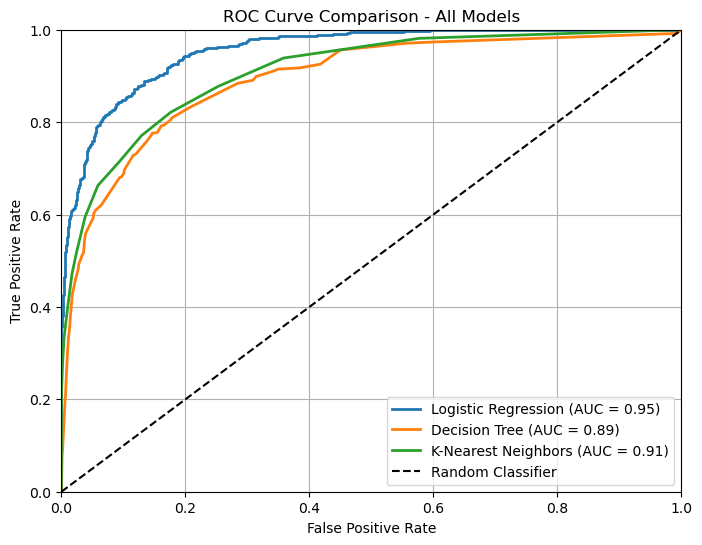

In [67]:
plt.figure(figsize=(8, 6))
for name, algo in models.items():
    algo.fit(X_train, y_train)
    y_prob = algo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {auc:.2f})'
    )
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier'
)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend()
plt.grid()

In [68]:
comparison_table = pd.DataFrame(result)
print("Comparison Table: \n")
print(comparison_table)

Comparison Table: 

                 Model  Accuracy  precision    recall  f1_score  \
0  Logistic Regression  0.892917   0.866270  0.777333  0.819396   
1        Decision Tree  0.836250   0.775889  0.669333  0.718683   
2  K-Nearest Neighbors  0.847083   0.876228  0.594667  0.708499   

   roc_auc_score  train accuracy  test accuracy  
0       0.954621        0.893750       0.892917  
1       0.892450        0.863750       0.836250  
2       0.908293        0.867292       0.847083  


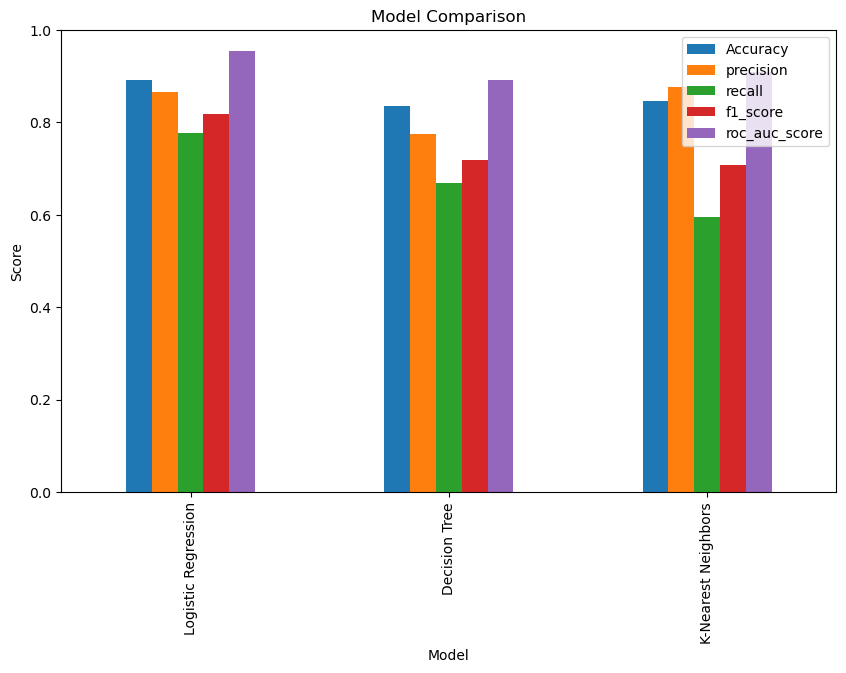

In [69]:
metrics = ['Accuracy', 'precision', 'recall', 'f1_score', 'roc_auc_score']
comparison_table.plot(
    x='Model',
    y=metrics,
    kind='bar',
    figsize=(10,6)
)
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('Model Comparison')
plt.show()